In [1]:
import os
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
np.random.seed(42)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [2]:
os.makedirs("CNN", exist_ok=True)

In [3]:
np.random.seed(42)
df = pd.read_csv(r"E:\my research\algo local\Cardiosense\swat_heart_disease_dataset.csv")

print("Dataset Shape:", df.shape)


Dataset Shape: (380, 12)


In [4]:
df.drop(columns=['ecg', 'rwma', 'trop', 'angio'], inplace=True)
df.drop_duplicates(inplace=True)

print(df.head())
print(df.info())


   age     sex      BP diabetes fhist Physical_Activity             cp target
0   85  Female    High      Yes    No              High      No Angina     No
1   63  Female     Low      Yes   Yes               Low  Stable Angina     No
2   77  Female  Normal      Yes   Yes              High      No Angina     No
3   77  Female  Normal      Yes   Yes          Moderate      No Angina    Yes
4   62  Female    High      Yes   Yes          Moderate  Stable Angina    Yes
<class 'pandas.core.frame.DataFrame'>
Index: 352 entries, 0 to 378
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                352 non-null    int64 
 1   sex                352 non-null    object
 2   BP                 352 non-null    object
 3   diabetes           352 non-null    object
 4   fhist              352 non-null    object
 5   Physical_Activity  352 non-null    object
 6   cp                 352 non-null    object
 7   targe

In [5]:
df['target'] = df['target'].map({'No': 0, 'Yes': 1})


In [6]:
X = df.drop(columns='target')
y = df['target']

In [7]:
np.random.seed(42)
transformer = ColumnTransformer(
    transformers=[

        # Scale numerical column
        ('num_age',
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),
             ('scaler', MinMaxScaler())
         ]),
         ['age']
        ),

        # OneHot Encoding
        ('onehot',
         OneHotEncoder(drop='first', handle_unknown='ignore'),
         ['sex', 'diabetes', 'fhist']
        ),

        # Ordinal Encoding
        ('cp',
         OrdinalEncoder(categories=[
             ['No Angina', 'Stable Angina', 'Unstable Angina']
         ]),
         ['cp']
        ),

        ('bp',
         OrdinalEncoder(categories=[
             ['Normal', 'Low', 'High']
         ]),
         ['BP']
        ),

        ('activity',
         OrdinalEncoder(categories=[
             ['High', 'Moderate', 'Low']
         ]),
         ['Physical_Activity']
        )

    ],
    remainder='passthrough'
)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [9]:
X_train_processed = transformer.fit_transform(X_train)
X_test_processed = transformer.transform(X_test)

# Convert sparse matrix to dense
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()


In [10]:
final_scaler = StandardScaler()

X_train_processed = final_scaler.fit_transform(X_train_processed)
X_test_processed = final_scaler.transform(X_test_processed)

print("Processed Train Shape:", X_train_processed.shape)
print("Processed Test Shape :", X_test_processed.shape)

Processed Train Shape: (264, 7)
Processed Test Shape : (88, 7)


In [11]:
class HeartDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y.values)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        # Shape: (features,) -> (1, features)
        return self.X[idx].unsqueeze(0), self.y[idx]


In [12]:
train_dataset = HeartDataset(X_train_processed, y_train)
test_dataset = HeartDataset(X_test_processed, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [13]:
class HeartCNN(nn.Module):

    def __init__(self, input_dim):

        super(HeartCNN, self).__init__()

        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.bn1 = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        self.bn2 = nn.BatchNorm1d(128)

        self.conv3 = nn.Conv1d(
            in_channels=128,
            out_channels=256,
            kernel_size=3,
            padding=1
        )

        self.bn3 = nn.BatchNorm1d(256)

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.3)

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 2)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.global_pool(x)

        x = x.squeeze(-1)

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)

        return x


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nUsing Device:", device)


Using Device: cpu


In [15]:
np.random.seed(42)
input_dim = X_train_processed.shape[1]
model = HeartCNN(input_dim=input_dim).to(device)

print(model)


HeartCNN(
  (conv1): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)


In [16]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [17]:
np.random.seed(42)
epochs = 100

train_losses = []

print("\nStarting Training...\n")

start_time = time.time()

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {epoch_loss:.4f}"
        )

end_time = time.time()

print("\nTraining Completed!")
print(f"Training Time: {(end_time - start_time):.2f} seconds")



Starting Training...

Epoch [10/100] Loss: 0.6299
Epoch [20/100] Loss: 0.5888
Epoch [30/100] Loss: 0.6038
Epoch [40/100] Loss: 0.5641
Epoch [50/100] Loss: 0.6082
Epoch [60/100] Loss: 0.5849
Epoch [70/100] Loss: 0.5435
Epoch [80/100] Loss: 0.5197
Epoch [90/100] Loss: 0.5270
Epoch [100/100] Loss: 0.6650

Training Completed!
Training Time: 31.96 seconds


In [18]:
model.eval()

all_preds = []
all_probs = []
all_labels = []
np.random.seed(42)
with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)

        outputs = model(inputs)

        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())
        all_labels.extend(labels.numpy())


In [19]:
accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(all_labels, all_preds)

recall = recall_score(all_labels, all_preds)

f1 = f1_score(all_labels, all_preds)

roc_auc = roc_auc_score(all_labels, all_probs)

print("\n================ PERFORMANCE ================\n")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")


================ PERFORMANCE ================

Accuracy : 0.4659
Precision: 0.4528
Recall   : 0.5714
F1 Score : 0.5053
ROC AUC  : 0.5417



Saved: CNN/confusion_matrix.png


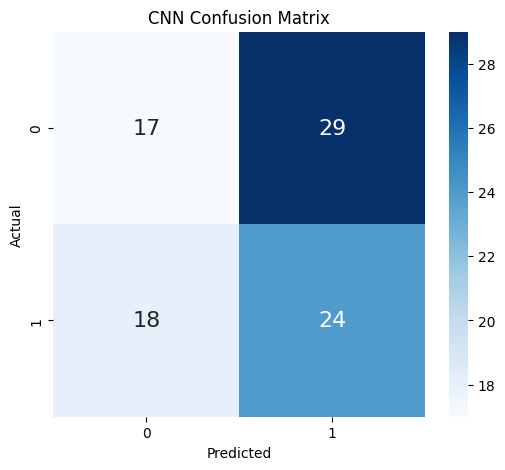

In [20]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    annot_kws={"size": 16}
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.savefig(
    "CNN/confusion_matrix.png",
    bbox_inches='tight',
    dpi=150
)

print("\nSaved: CNN/confusion_matrix.png")

plt.show()


C:\Users\Muhammad Naeem\AppData\Local\Temp\ipykernel_16860\172968567.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Saved: CNN/CNN_performance.png


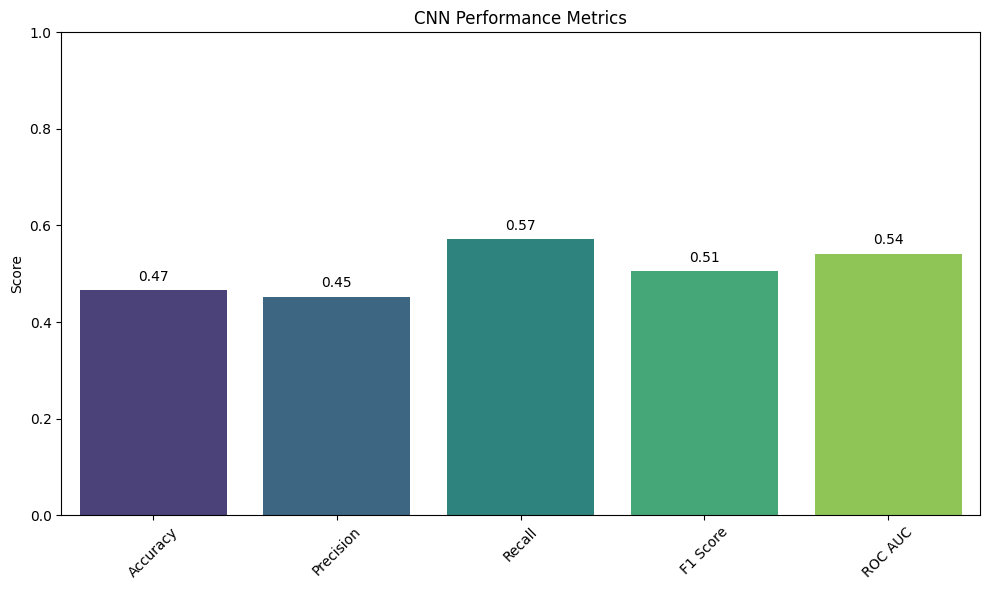

In [21]:
metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'ROC AUC': roc_auc
}

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=list(metrics.keys()),
    y=list(metrics.values()),
    palette='viridis'
)

for i, value in enumerate(metrics.values()):

    ax.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha='center',
        fontsize=10
    )

plt.ylim(0, 1)

plt.title("CNN Performance Metrics")

plt.ylabel("Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "CNN/CNN_performance.png",
    bbox_inches='tight',
    dpi=150
)

print("Saved: CNN/CNN_performance.png")

plt.show()


Saved: CNN/training_loss.png


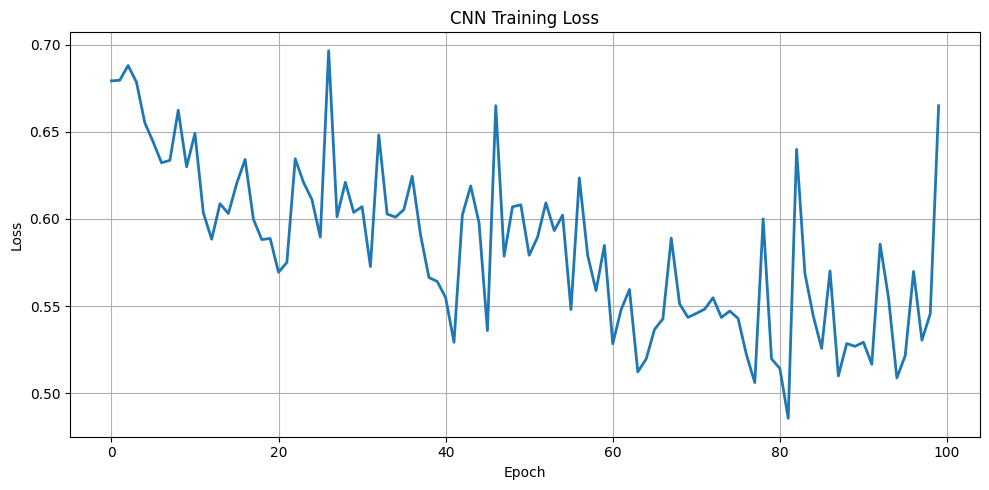


Saved Model: CNN/cnn_model.pth

All files saved successfully!


In [22]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "CNN/training_loss.png",
    bbox_inches='tight',
    dpi=150
)

print("Saved: CNN/training_loss.png")

plt.show()
torch.save(model.state_dict(), "CNN/cnn_model.pth")

print("\nSaved Model: CNN/cnn_model.pth")

print("\nAll files saved successfully!")

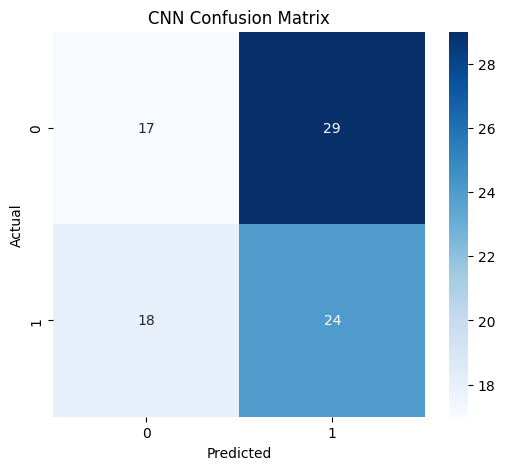

Saved: CNN/confusion_matrix.png


C:\Users\Muhammad Naeem\AppData\Local\Temp\ipykernel_16860\3758347295.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')


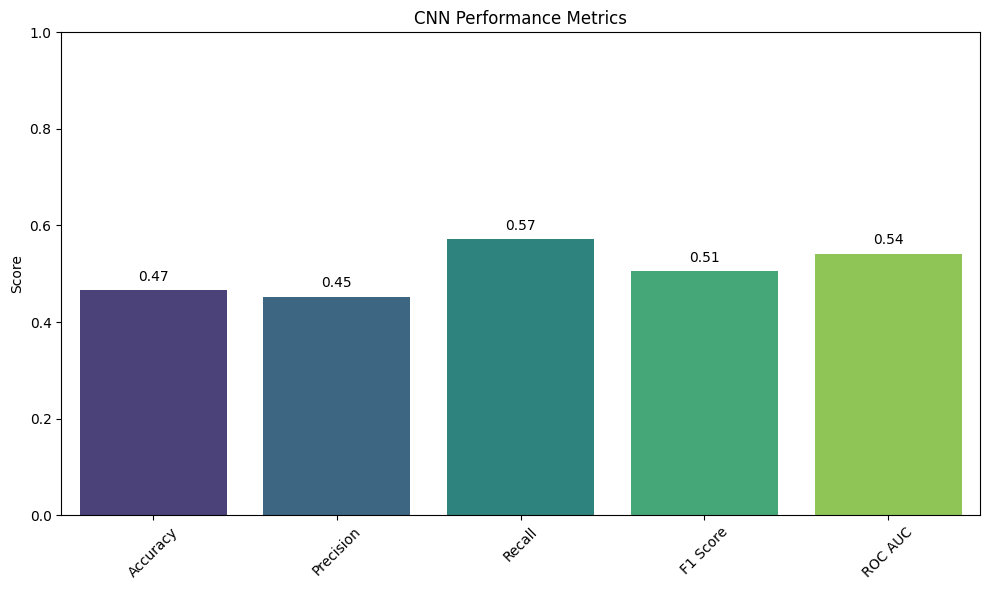

Saved: CNN/CNN_performance.png


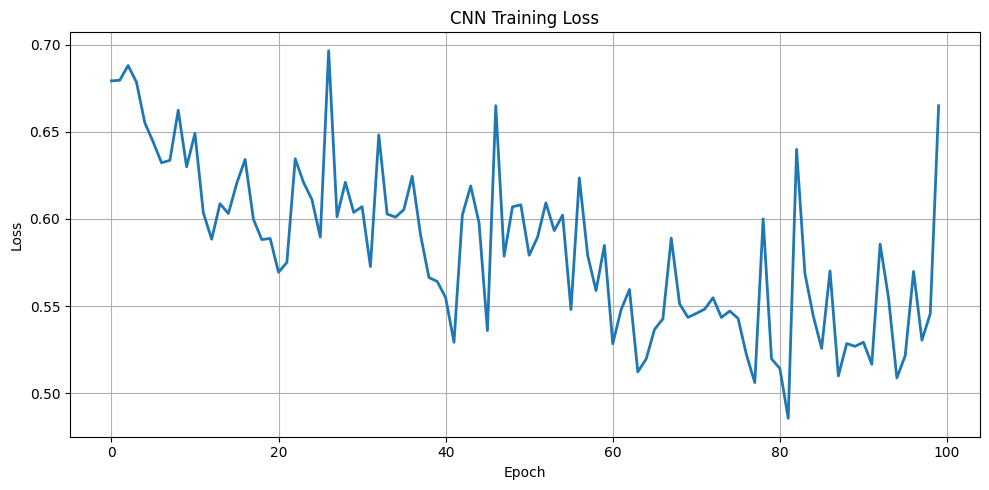

Saved: CNN/training_loss.png


NameError: name 'roc_curve' is not defined

In [23]:

# ─────────────────────────────────────────────
# 7. CONFUSION MATRIX
# ─────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.savefig("CNN/confusion_matrix.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: CNN/confusion_matrix.png")
 
# ─────────────────────────────────────────────
# 8. PERFORMANCE BAR CHART
# ─────────────────────────────────────────────
metrics = {
    'Accuracy': accuracy, 'Precision': precision,
    'Recall': recall, 'F1 Score': f1, 'ROC AUC': roc_auc
}
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')
for i, v in enumerate(metrics.values()):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10)
plt.ylim(0, 1)
plt.title("CNN Performance Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("CNN/CNN_performance.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: CNN/CNN_performance.png")
 
# ─────────────────────────────────────────────
# 9. TRAINING LOSS CURVE
# ─────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(train_losses, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig("CNN/training_loss.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: CNN/training_loss.png")
 
# ─────────────────────────────────────────────
# 10. ROC CURVE
# ─────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc_value = auc(fpr, tpr)
 
plt.figure(figsize=(8, 6))
 
# ROC curve
plt.plot(
    fpr, tpr,
    color='darkorange',
    linewidth=2,
    label=f'CNN ROC Curve (AUC = {roc_auc_value:.4f})'
)
 
# Random classifier baseline
plt.plot(
    [0, 1], [0, 1],
    color='navy',
    linewidth=1.5,
    linestyle='--',
    label='Random Classifier (AUC = 0.50)'
)
 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve – CNN Heart Disease Detection', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("CNN/roc_curve.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: CNN/roc_curve.png")
 
# Save model
torch.save(model.state_dict(), "CNN/cnn_model.pth")
print("\nSaved Model: CNN/cnn_model.pth")
print("\nAll files saved successfully!")
 

Dataset Shape: (380, 12)
Duplicates before: 0
Duplicates after : 0
Processed Train Shape: (264, 7)
Processed Test Shape : (88, 7)

Using Device: cpu
HeartCNN(
  (conv1): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)

Starting Training...

Epoch [10/100]  Train Loss: 0.6201  Val 

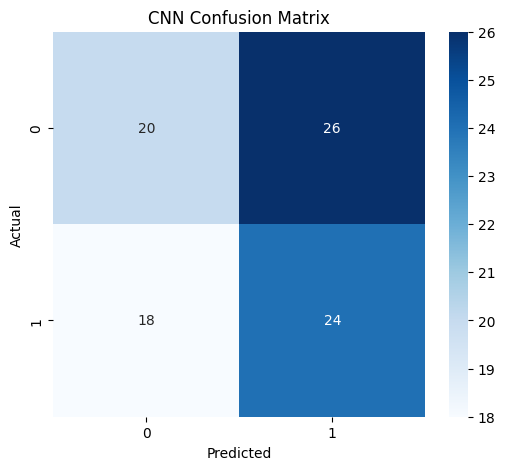

Saved: CNN/confusion_matrix.png


C:\Users\Muhammad Naeem\AppData\Local\Temp\ipykernel_14192\4018035287.py:307: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')


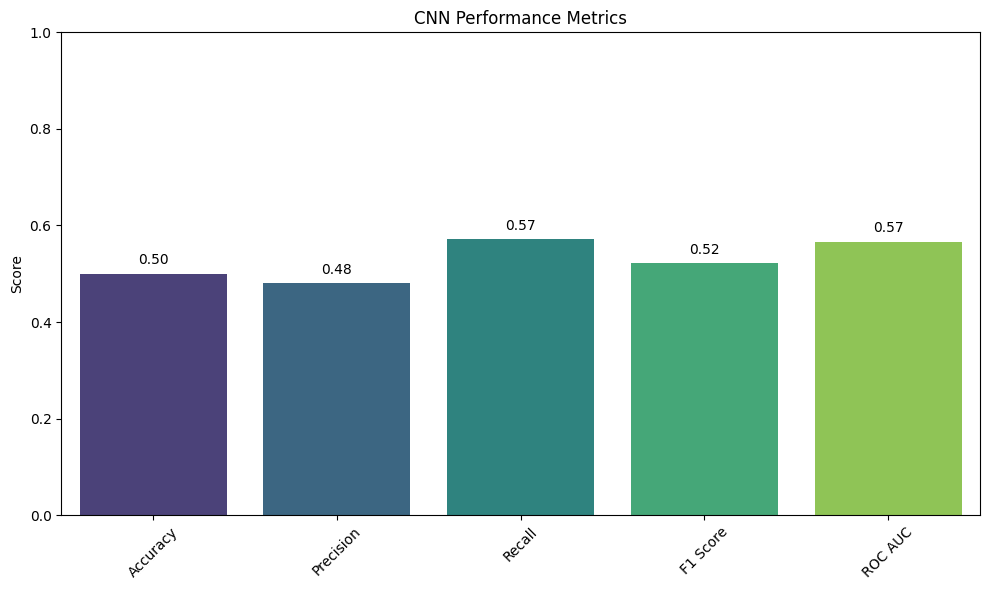

Saved: CNN/CNN_performance.png


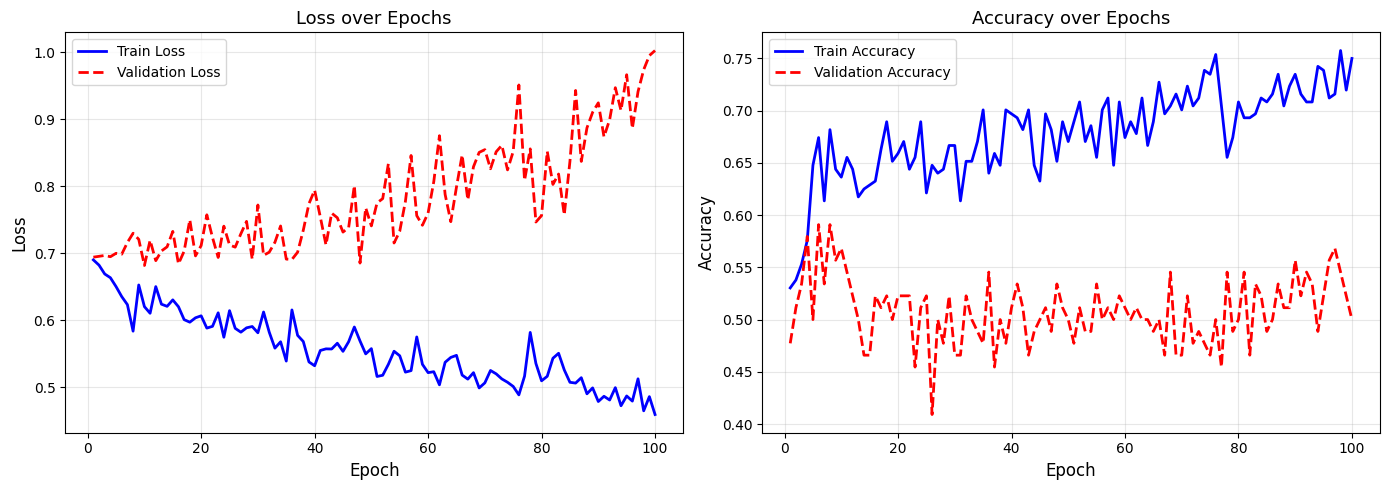

Saved: CNN/loss_accuracy_curves.png


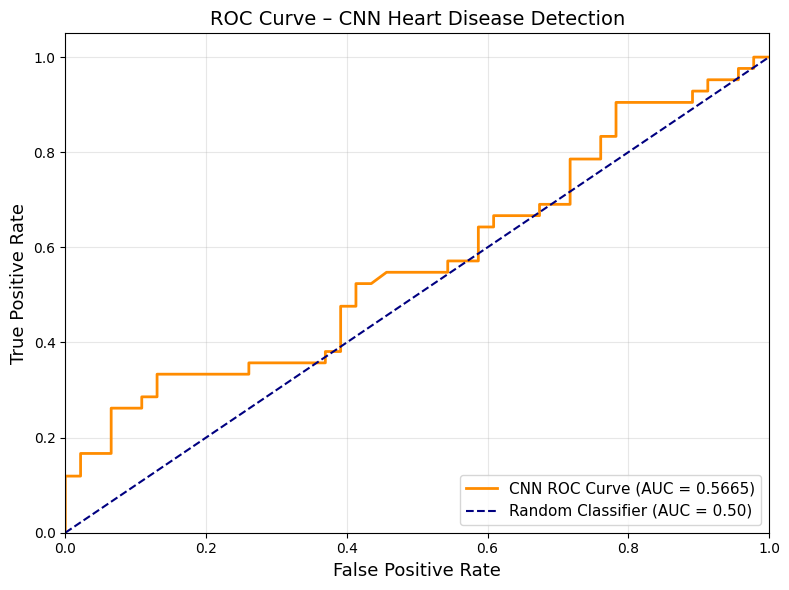

Saved: CNN/roc_curve.png

Saved Model: CNN/cnn_model.pth

All files saved successfully!


In [ ]:

import os
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
 
import torch
import torch.nn as nn
import torch.optim as optim
 
from torch.utils.data import Dataset, DataLoader
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix
)
 
np.random.seed(42)
torch.manual_seed(42)
 
# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
os.makedirs("CNN", exist_ok=True)
 
df = pd.read_csv(r"E:\my research\algo local\heart disease detection\swat_heart_disease_dataset.csv")
print("Dataset Shape:", df.shape)
 
# ─────────────────────────────────────────────
# 2. PREPROCESSING
# ─────────────────────────────────────────────
df.drop(columns=['ecg', 'rwma', 'trop', 'angio'], inplace=True)
df.drop_duplicates(inplace=True)
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after :", df.duplicated().sum())
 
df['target'] = df['target'].map({'No': 0, 'Yes': 1})
 
X = df.drop(columns='target')
y = df['target']
 
transformer = ColumnTransformer(
    transformers=[
 
        # Scale numerical column
        ('num_age',
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),
             ('scaler', MinMaxScaler())
         ]),
         ['age']
        ),
 
        # OneHot Encoding
        ('onehot',
         OneHotEncoder(drop='first', handle_unknown='ignore'),
         ['sex', 'diabetes', 'fhist']
        ),
 
        # Ordinal Encoding
        ('cp',
         OrdinalEncoder(categories=[
             ['No Angina', 'Stable Angina', 'Unstable Angina']
         ]),
         ['cp']
        ),
 
        
 
        ('bp',
         OrdinalEncoder(categories=[
             ['Normal', 'Low', 'High']
         ]),
         ['BP']
        ),
 
        ('activity',
         OrdinalEncoder(categories=[
             ['High', 'Moderate', 'Low']
         ]),
         ['Physical_Activity']
        ),
 
    ],
    remainder='passthrough'
)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
 
X_train_processed = transformer.fit_transform(X_train)
X_test_processed  = transformer.transform(X_test)
 
# Convert sparse matrix to dense if needed
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()
 
final_scaler = StandardScaler()
X_train_processed = final_scaler.fit_transform(X_train_processed)
X_test_processed  = final_scaler.transform(X_test_processed)
 
print("Processed Train Shape:", X_train_processed.shape)
print("Processed Test Shape :", X_test_processed.shape)
 
# ─────────────────────────────────────────────
# 3. DATASET & DATALOADER
# ─────────────────────────────────────────────
class HeartDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y.values)
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        return self.X[idx].unsqueeze(0), self.y[idx]   # (1, features)
 
 
train_dataset = HeartDataset(X_train_processed, y_train)
test_dataset  = HeartDataset(X_test_processed,  y_test)
 
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)
 
# ─────────────────────────────────────────────
# 4. MODEL
# ─────────────────────────────────────────────
class HeartCNN(nn.Module):
    def __init__(self, input_dim):
        super(HeartCNN, self).__init__()
 
        self.conv1 = nn.Conv1d(in_channels=1,   out_channels=64,  kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm1d(64)
 
        self.conv2 = nn.Conv1d(in_channels=64,  out_channels=128, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(128)
 
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm1d(256)
 
        self.relu        = nn.ReLU()
        self.dropout     = nn.Dropout(0.3)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
 
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64,  2)
 
    def forward(self, x):
        x = self.dropout(self.relu(self.bn1(self.conv1(x))))
        x = self.dropout(self.relu(self.bn2(self.conv2(x))))
        x = self.dropout(self.relu(self.bn3(self.conv3(x))))
        x = self.global_pool(x).squeeze(-1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)
 
 
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_processed.shape[1]
model     = HeartCNN(input_dim=input_dim).to(device)
 
print("\nUsing Device:", device)
print(model)
 
# ─────────────────────────────────────────────
# 5. TRAINING
# ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
 
epochs       = 100
train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []
 
print("\nStarting Training...\n")
start_time = time.time()
 
for epoch in range(epochs):
 
    # ── Train ──
    model.train()
    running_loss    = 0.0
    correct_train   = 0
    total_train     = 0
 
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
 
        running_loss  += loss.item()
        _, preds       = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train   += labels.size(0)
 
    train_losses.append(running_loss / len(train_loader))
    train_accs.append(correct_train / total_train)
 
    # ── Validate ──
    model.eval()
    val_loss      = 0.0
    correct_val   = 0
    total_val     = 0
 
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
 
            val_loss    += loss.item()
            _, preds     = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val   += labels.size(0)
 
    val_losses.append(val_loss / len(test_loader))
    val_accs.append(correct_val / total_val)
 
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}]  "
            f"Train Loss: {train_losses[-1]:.4f}  Val Loss: {val_losses[-1]:.4f}  "
            f"Train Acc: {train_accs[-1]:.4f}  Val Acc: {val_accs[-1]:.4f}"
        )
 
print(f"\nTraining Completed in {time.time() - start_time:.2f}s")
 
# ─────────────────────────────────────────────
# 6. EVALUATION
# ─────────────────────────────────────────────
model.eval()
all_preds, all_probs, all_labels = [], [], []
 
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs  = inputs.to(device)
        outputs = model(inputs)
        probs   = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
 
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())
        all_labels.extend(labels.numpy())
 
accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall    = recall_score(all_labels, all_preds)
f1        = f1_score(all_labels, all_preds)
roc_auc   = roc_auc_score(all_labels, all_probs)
 
print("\n================ PERFORMANCE ================\n")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")
 
# ─────────────────────────────────────────────
# 7. CONFUSION MATRIX
# ─────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.savefig("CNN/confusion_matrix.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: CNN/confusion_matrix.png")
 
# ─────────────────────────────────────────────
# 8. PERFORMANCE BAR CHART
# ─────────────────────────────────────────────
metrics = {
    'Accuracy': accuracy, 'Precision': precision,
    'Recall': recall, 'F1 Score': f1, 'ROC AUC': roc_auc
}
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')
for i, v in enumerate(metrics.values()):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10)
plt.ylim(0, 1)
plt.title("CNN Performance Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("CNN/CNN_performance.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: CNN/CNN_performance.png")
 
# ─────────────────────────────────────────────
# 9. LOSS & ACCURACY CURVES (side by side)
# ─────────────────────────────────────────────
epochs_range = range(1, epochs + 1)
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
# Left: Loss over Epochs
ax2.plot(epochs_range, train_accs, color='blue', linewidth=2,
         linestyle='-',  label='Train Accuracy')
ax2.plot(epochs_range, val_accs,   color='red',  linewidth=2,
         linestyle='--', label='Validation Accuracy')
ax2.set_xlabel('Epoch',    fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy over Epochs', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
# Right: Accuracy over Epochs
ax1.plot(epochs_range, train_losses, color='blue', linewidth=2,
         linestyle='-',  label='Train Loss')
ax1.plot(epochs_range, val_losses,   color='red',  linewidth=2,
         linestyle='--', label='Validation Loss')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss',  fontsize=12)
ax1.set_title('Loss over Epochs', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("CNN/loss_accuracy_curves.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: CNN/loss_accuracy_curves.png")
 
# ─────────────────────────────────────────────
# 10. ROC CURVE
# ─────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc_value = auc(fpr, tpr)
 
plt.figure(figsize=(8, 6))
 
# ROC curve
plt.plot(
    fpr, tpr,
    color='darkorange',
    linewidth=2,
    label=f'CNN ROC Curve (AUC = {roc_auc_value:.4f})'
)
 
# Random classifier baseline
plt.plot(
    [0, 1], [0, 1],
    color='navy',
    linewidth=1.5,
    linestyle='--',
    label='Random Classifier (AUC = 0.50)'
)
 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve – CNN Heart Disease Detection', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("CNN/roc_curve.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: CNN/roc_curve.png")
 
# Save model
torch.save(model.state_dict(), "CNN/cnn_model.pth")
print("\nSaved Model: CNN/cnn_model.pth")
print("\nAll files saved successfully!")